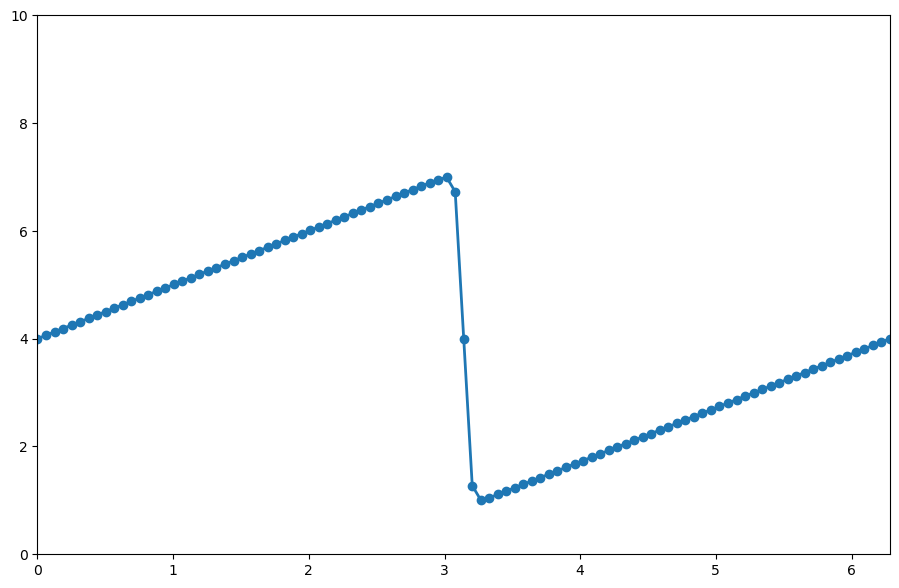

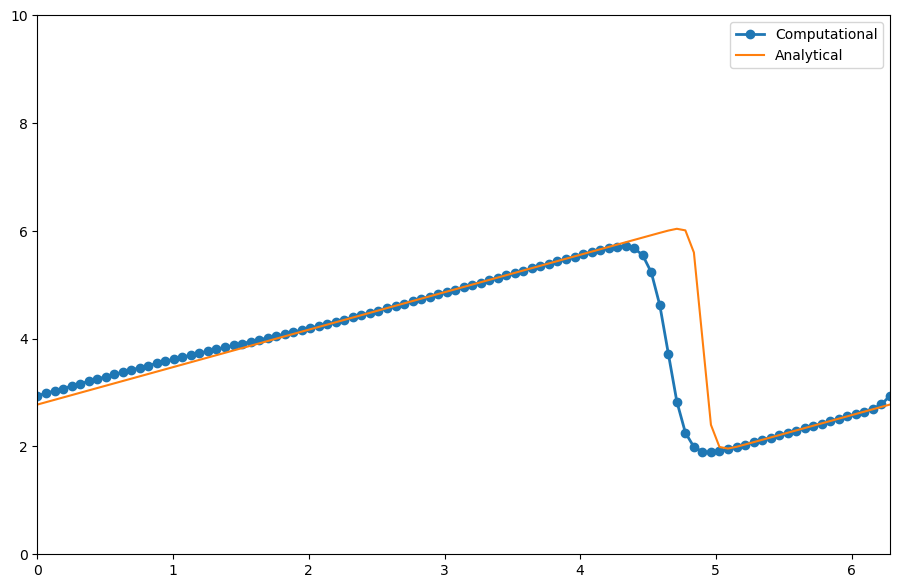

In [52]:
import numpy
import sympy

from sympy import init_printing
init_printing(use_latex=True)        # 进行渲染

x, nu, t = sympy.symbols('x nu t')
phi = (sympy.exp(-(x - 4 * t)**2 / (4 * nu * (t+1))) + sympy.exp(-(x - 4 * t - 2 * sympy.pi)**2 / (4 * nu * (t + 1))))

phiprime = phi.diff(x)  # 计算 ∂φ/∂x 也就是phi对x偏导数
phiprime
# 边界条件为u(0)=u(2π) 周期性

from sympy.utilities.lambdify import lambdify # lambdify函数用于将 SymPy 的符号表达式转换为普通的 Python 函数（通常基于 NumPy），以便进行高效的数值计算。

u = -2 * nu * (phiprime / phi) + 4  # 标准的 Hopf-Cole 逆变换形式
# print(u)

ufunc = lambdify((t, x, nu), u)     # 使用 lambdify 将符号表达式 u 转换为数值函数 ufunc 精确解
# print(ufunc(1, 4, 3))               # 带入参数

from matplotlib import pyplot

nx = 101
nt = 100
dx = 2 * numpy.pi / (nx -1)  # 空间步长 2*pi/100=0.0628
nu = 0.07                    # Re ≈ L·U / ν ≈ 2π·4 / 0.07 ≈ 360
dt = dx * nu

x = numpy.linspace(0, 2 * numpy.pi, nx)  # 生成空间坐标数组 x，从 0 到 2π（包含端点），共 101 个等间距点
un = numpy.empty(nx)                     # 用于在时间推进循环中存储下一时刻的速度场
t = 0                            # 初始化时间

u = numpy.asarray([ufunc(t, x0, nu) for x0 in x])  # 计算的对象：速度场 u 的初始值，即 u(x, t=0)
# u

pyplot.figure(figsize=(11, 7), dpi=100)
pyplot.plot(x, u, marker='o', lw=2)
pyplot.xlim([0, 2 * numpy.pi]);
pyplot.ylim([0, 10]);

for n in range(nt):
    un = u.copy()       # 从t=0到t ≈ 0.44
    for i in range(1, nx-1):
        u[i] = un[i] \ 
        - un[i] * dt / dx * (un[i] - un[i-1]) \            # 对流（向后差分
        + nu * dt / dx**2 * (un[i+1] - 2*un[i] + un[i-1])  # 扩散项（中心差分

    # 边界处理：严格周期边界条件 u(0) = u(2π)，通过复制左边界值到右边界实现。
    u[0] = un[0] - un[0] * dt / dx * (un[0] - un[-1]) + nu * dt / dx**2 * (un[1] - 2*un[0] + un[-2])   # 左边界
    u[-1] = u[0]                                                                                       # 右边界

u_analytical = numpy.asarray([ufunc(nt * dt, xi, nu) for xi in x]) # nt * dt ≈ 0.44 求出解析解
# u_analytical

pyplot.figure(figsize=(11, 7), dpi=100)
pyplot.plot(x, u, marker='o', lw=2, label='Computational')    # 数值解 u 
pyplot.plot(x, u_analytical, label='Analytical')              # 解析解 u_analytical
pyplot.xlim([0, 2 * numpy.pi])
pyplot.ylim([0, 10])
pyplot.legend();
